In [2]:
%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import time


In [4]:
def generate_noise_layer(shape, freq, seed=None):
    """
    生成一层平滑的噪声（Value Noise）。
    使用低分辨率随机网格 + 双三次插值（Bicubic Interpolation）模拟。
    """
    if seed is not None:
        np.random.seed(seed)
    
    # 生成低频的随机网格
    # 我们额外加一些缓冲（padding）以避免边缘伪影，但在zoom中直接处理更简单
    # 这里直接生成对应频率的随机点
    grid_size = (freq, freq)
    random_grid = np.random.rand(*grid_size)
    
    # 计算缩放因子，将低频网格拉伸到目标尺寸
    zoom_factor = (shape[0] / freq, shape[1] / freq)
    
    # 使用 order=3 (双三次插值) 使噪声更平滑，接近 Perlin/Simplex 的效果
    noise = zoom(random_grid, zoom_factor, order=3)
    
    # 裁剪到确切的目标尺寸（因为zoom可能会有微小的浮点误差）
    noise = noise[:shape[0], :shape[1]]
    
    # 归一化到 -1 到 1 之间
    return (noise - 0.5) * 2.0


In [5]:
def generate_mountain_terrain(size=1024, octaves=10, persistence=0.5, lacunarity=2.0, slope_damping=1.5, seed=int(time.time())):
    """
    使用“梯度技巧”生成山脉地形。
    
    参数:
    - size: 地图分辨率
    - octaves: 噪声叠加层数
    - persistence: 振幅衰减系数
    - lacunarity: 频率增长系数
    - slope_damping: 坡度对细节的抑制强度（关键参数！）
    - seed: 随机种子
    """
    print(f"正在生成 {size}x{size} 地形...")
    start_time = time.time()
    
    # 初始化地形高度图
    terrain = np.zeros((size, size))
    
    amplitude = 1.0
    frequency = 2  # 初始频率
    max_value = 0  # 用于最后的归一化
    
    # 随机种子，保证每层噪声独立但可复现（可选）
    base_seed = seed

    for i in range(octaves):
        print(f"  正在处理第 {i+1}/{octaves} 层 (频率: {frequency})")
        
        # 1. 生成当前层的噪声
        noise_layer = generate_noise_layer((size, size), frequency, seed=base_seed + i)
        
        # 2. 计算当前地形的梯度（坡度）
        # np.gradient 返回 [gy, gx]，我们计算梯度的模长（magnitude）
        # 注意：第一层时地形为0，梯度为0，不做抑制
        gy, gx = np.gradient(terrain)
        gradient_magnitude = np.sqrt(gx**2 + gy**2)
        
        # 3. 计算抑制因子 (The Gradient Trick)
        # 坡度越大，因子越小 (接近0)；坡度平缓，因子接近1
        # 公式: weight = 1 / (1 + k * gradient^2)
        erosion_mask = 1.0 / (1.0 + slope_damping * (gradient_magnitude ** 2))
        
        # 4. 叠加噪声
        # 新的一层噪声不仅受振幅控制，还受“侵蚀掩码”控制
        terrain += noise_layer * amplitude * erosion_mask
        
        # 更新参数
        max_value += amplitude
        amplitude *= persistence
        frequency = int(frequency * lacunarity)
        
        # 频率不能超过分辨率
        if frequency > size:
            break
    
    return terrain

In [6]:
# 后处理部分分离
def postprocess_terrain(terrain, norm_factor=8.0, blur=1):
    """
    进行地形的后处理：增强梯度和高斯模糊。
    参数:
    - terrain: 输入地形高度图
    - norm_factor: 梯度增强因子
    - blur: 高斯模糊的标准差
    """
    # 增强靠近0和1的梯度（拉伸两端，压缩中间）
    a = norm_factor
    norm = (terrain - np.min(terrain)) / (np.max(terrain) - np.min(terrain))
    terrain = (1 / (1 + np.exp(-a * (norm - 0.5))) - 1 / (1 + np.exp(a * 0.5))) / (1 / (1 + np.exp(-a * 0.5)) - 1 / (1 + np.exp(a * 0.5)))
    from scipy.ndimage import gaussian_filter
    terrain = gaussian_filter(terrain, sigma=blur)
    return terrain

In [7]:
# 运行算法
map_size = 1024
terrain = generate_mountain_terrain(
	size=map_size, 
	octaves=12, 
	# persistence=0.43,
	# lacunarity=2,
	slope_damping=1000, # 调大这个值，山脊会更明显，细节更少出现在陡坡上
	seed=2147,
)

正在生成 1024x1024 地形...
  正在处理第 1/12 层 (频率: 2)
  正在处理第 2/12 层 (频率: 4)
  正在处理第 3/12 层 (频率: 8)
  正在处理第 4/12 层 (频率: 16)
  正在处理第 5/12 层 (频率: 32)
  正在处理第 6/12 层 (频率: 64)
  正在处理第 7/12 层 (频率: 128)
  正在处理第 8/12 层 (频率: 256)
  正在处理第 9/12 层 (频率: 512)
  正在处理第 10/12 层 (频率: 1024)


图片已保存为: gradient_terrain.png


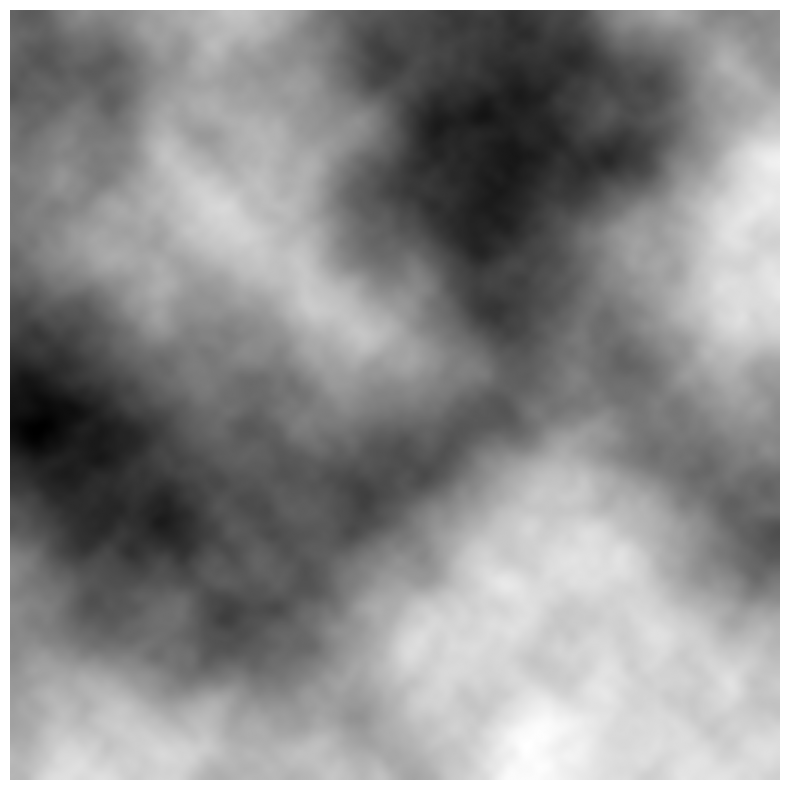

In [ ]:
height_map = postprocess_terrain(terrain, norm_factor=1, blur=4)

# 显示和保存结果
plt.figure(figsize=(10, 10))
plt.imshow(height_map, origin='lower', cmap='gray')
# plt.title("Procedural Terrain using Gradient Trick")
plt.axis('off')

output_filename = "gradient_terrain.png"
# plt.savefig(output_filename, bbox_inches='tight', pad_inches=0)
print(f"图片已保存为: {output_filename}")
plt.show()

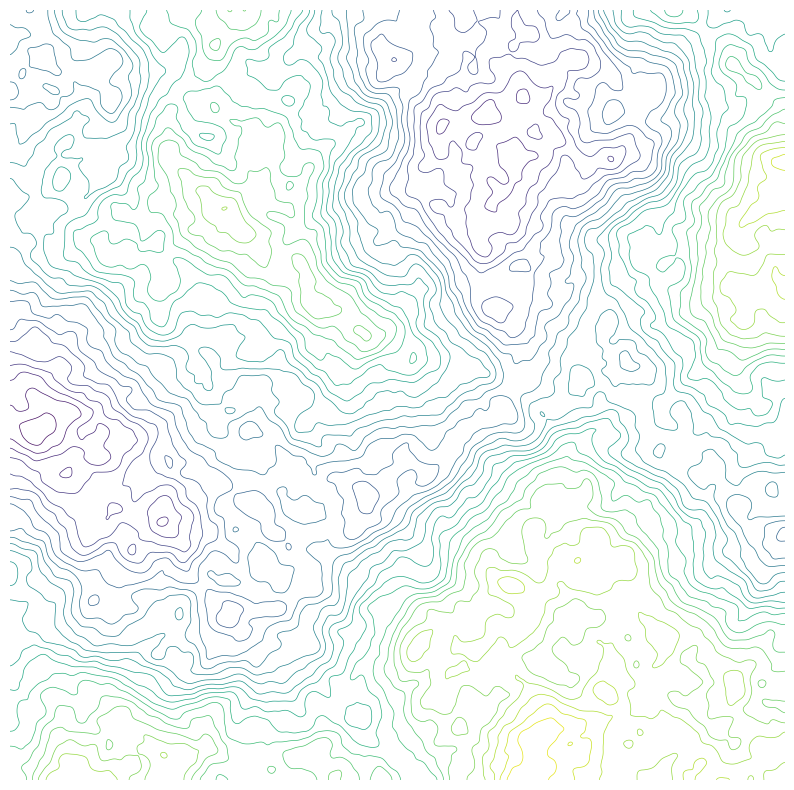

In [9]:
# 生成等高线图
plt.figure(figsize=(10, 10))
contour_levels = 24
plt.contour(height_map, levels=contour_levels, linewidths=0.5, origin='lower')
plt.axis('off')
plt.savefig("contour_map.svg", bbox_inches='tight', pad_inches=0)
plt.show()

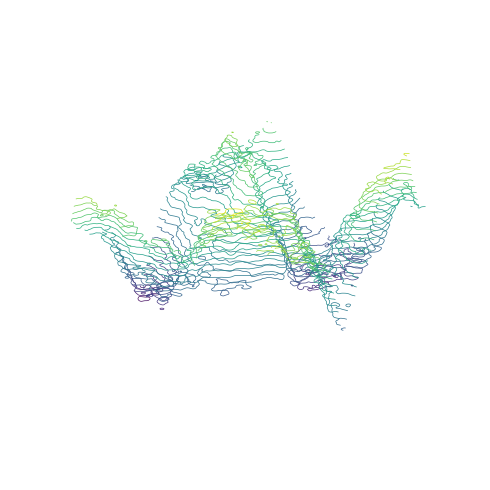

In [10]:
# 3D 等高线图
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(height_map.shape[1]), np.arange(height_map.shape[0]))
ax.contour3D(X, Y, height_map, levels=contour_levels, linewidths=0.5)
ax.set_axis_off()
plt.tight_layout()
plt.show()

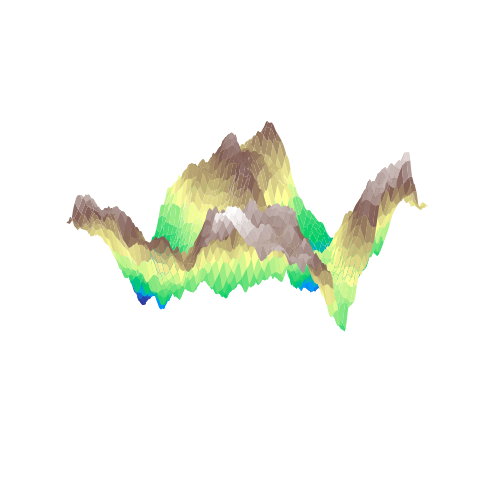

In [11]:
# 3D 体积图
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, height_map, cmap='terrain', edgecolor='none')
ax.set_axis_off()
plt.tight_layout()
plt.show()

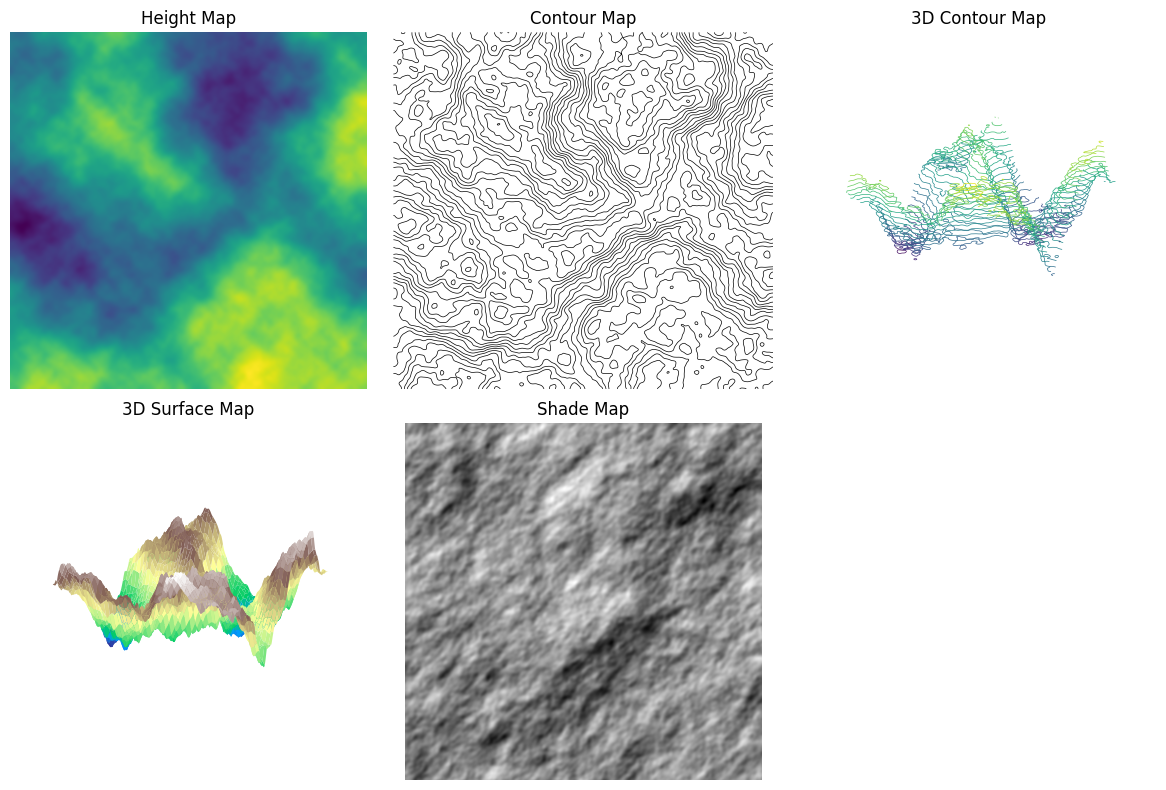

In [12]:
from matplotlib.colors import LightSource

# show all in a 2x3 grid
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(2, 3, 1)
ax1.imshow(height_map, origin='lower')
ax1.set_title("Height Map")
ax1.axis('off')

ax2 = fig.add_subplot(2, 3, 2)
ax2.contour(height_map, levels=contour_levels, linewidths=0.5, origin='lower', colors='black')
ax2.set_title("Contour Map")
ax2.axis('off')

ax3 = fig.add_subplot(2, 3, 3, projection='3d')
ax3.contour3D(X, Y, height_map, levels=contour_levels, linewidths=0.5)
ax3.set_title("3D Contour Map")
ax3.set_axis_off()

ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.plot_surface(X, Y, height_map, cmap='terrain', edgecolor='none')
ax4.set_title("3D Surface Map")
ax4.set_axis_off()

# Shade map (hillshade effect)
ls = LightSource(azdeg=45, altdeg=45)
shaded_map = ls.hillshade(height_map, vert_exag=10)
ax5 = fig.add_subplot(2, 3, 5)
ax5.imshow(shaded_map, cmap='gray', origin='lower')
ax5.set_title("Shade Map")
ax5.axis('off')

plt.tight_layout()
plt.show()